# Clase 8 - Aprendizaje Supervisado

## Notebook 1: Clasificación vs Regresión

Alumno: Sara Valenzuela

Materia: Minería de Datos

Objetivo:
Diferenciar problemas de clasificación y regresión mediante la aplicación de Regresión Logística y Regresión Lineal utilizando el dataset Titanic.

## Importación de librerías

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split

In [2]:
## Carga del Dataset Titanic
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [9]:
print("Dimensiones del dataset:", df.shape)

df.info()

Dimensiones del dataset: (182, 15)
<class 'pandas.core.frame.DataFrame'>
Index: 182 entries, 1 to 889
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     182 non-null    int64   
 1   pclass       182 non-null    int64   
 2   sex          182 non-null    object  
 3   age          182 non-null    float64 
 4   sibsp        182 non-null    int64   
 5   parch        182 non-null    int64   
 6   fare         182 non-null    float64 
 7   embarked     182 non-null    object  
 8   class        182 non-null    category
 9   who          182 non-null    object  
 10  adult_male   182 non-null    bool    
 11  deck         182 non-null    category
 12  embark_town  182 non-null    object  
 13  alive        182 non-null    object  
 14  alone        182 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 18.2+ KB


In [10]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,182.000000,182.000000,182.000000,182.000000,182.000000,182.000000
mean,0.675824,1.192308,35.623187,0.467033,0.478022,78.919735
std,0.469357,0.516411,15.671615,0.645007,0.755869,76.490774
min,0.000000,1.000000,0.920000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,24.000000,0.000000,0.000000,29.700000
50%,1.000000,1.000000,36.000000,0.000000,0.000000,57.000000
75%,1.000000,1.000000,47.750000,1.000000,1.000000,90.000000
max,1.000000,3.000000,80.000000,3.000000,4.000000,512.329200


## Identificación del tipo de problema

La variable "survived" representa si un pasajero sobrevivió o no al accidente del Titanic. Como posee valores discretos (0 = no sobrevivió, 1 = sobrevivió), corresponde a un problema de clasificación.

La variable "fare" representa el precio del boleto y puede tomar múltiples valores numéricos continuos. Por lo tanto, corresponde a un problema de regresión.

## Preparación de los datos

In [4]:

# Eliminamos registros con valores faltantes
df = df.dropna()

# Variables para clasificación
X_class = df[["age", "fare"]]
y_class = df["survived"]

# Variables para regresión
X_reg = df[["age"]]
y_reg = df["fare"]

print("Cantidad de registros:", len(df))

Cantidad de registros: 182


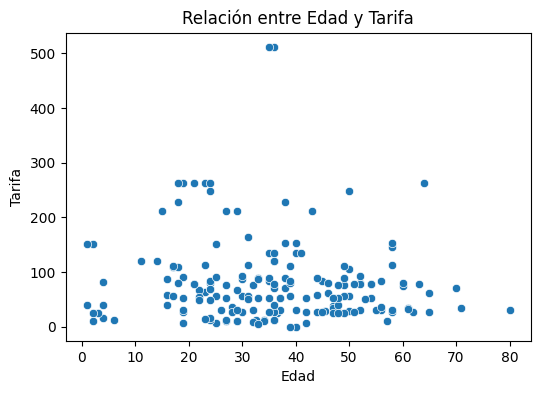

In [11]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="age", y="fare")

plt.title("Relación entre Edad y Tarifa")
plt.xlabel("Edad")
plt.ylabel("Tarifa")

plt.show()

In [5]:
## División de entrenamiento y prueba
X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X_class, y_class,
    test_size=0.2,
    random_state=42
)

X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X_reg, y_reg,
    test_size=0.2,
    random_state=42
)

In [6]:
## Aplicación de Regresión Logística y Regresión Lineal
clf = LogisticRegression(max_iter=1000)
clf.fit(X_tr_c, y_tr_c)

reg = LinearRegression()
reg.fit(X_tr_r, y_tr_r)

print("Modelos entrenados correctamente")

Modelos entrenados correctamente


In [7]:
print(f"Precisión Logística: {clf.score(X_te_c, y_te_c):.2f}")
print(f"R² Lineal: {reg.score(X_te_r, y_te_r):.2f}")

Precisión Logística: 0.73
R² Lineal: 0.04


## Comparación de Modelos

La Regresión Logística obtuvo una precisión de 0.73, lo que indica que clasificó correctamente aproximadamente el 73% de los pasajeros.

La Regresión Lineal obtuvo un R² de 0.04, indicando que la edad tiene una capacidad muy limitada para explicar la variación en la tarifa del boleto.

Los resultados muestran que ambos modelos cumplen funciones diferentes y deben utilizarse según el tipo de variable objetivo.

## Visualización de los resultados

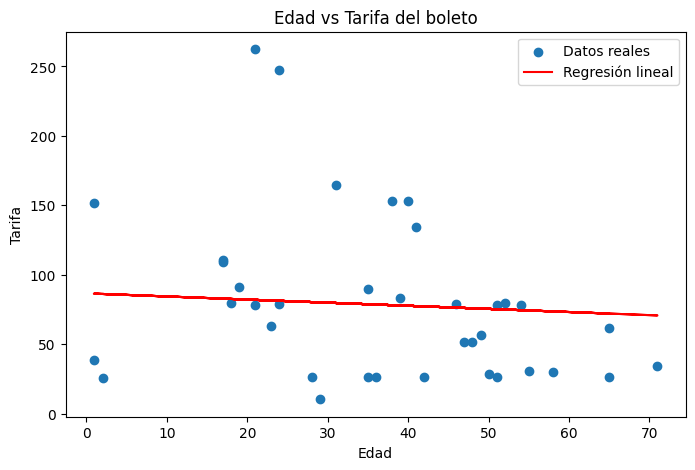

In [8]:

# Predicciones

y_pred_reg = reg.predict(X_te_r)

plt.figure(figsize=(8,5))

plt.scatter(X_te_r, y_te_r, label="Datos reales")
plt.plot(X_te_r, y_pred_reg, color="red", label="Regresión lineal")

plt.title("Edad vs Tarifa del boleto")
plt.xlabel("Edad")
plt.ylabel("Tarifa")
plt.legend()

plt.show()

## Interpretación de resultados

- La Regresión Logística obtuvo una precisión de 0.73, indicando que logró clasificar correctamente aproximadamente el 73% de los casos.

- La Regresión Lineal obtuvo un R² de 0.04, lo que indica que la edad explica muy poco la variación en la tarifa del boleto.

- Esto demuestra que la supervivencia es un problema de clasificación, mientras que la tarifa corresponde a un problema de regresión.

## Preguntas de Reflexión

### ¿Por qué es más adecuado usar Regresión Logística para predecir la supervivencia?

Porque la variable objetivo posee dos categorías posibles: sobrevivió o no sobrevivió. La Regresión Logística está diseñada para problemas de clasificación binaria.

### ¿Por qué la Regresión Lineal es más apropiada para predecir la tarifa del boleto?

Porque la tarifa es una variable numérica continua. La Regresión Lineal permite estimar valores numéricos a partir de otras variables.

### ¿Qué características adicionales podrían mejorar los modelos?

Podrían incorporarse variables como sexo, clase del pasajero (pclass), cantidad de familiares a bordo (sibsp y parch) o puerto de embarque. Estas variables podrían aportar información adicional y mejorar la capacidad predictiva de los modelos.

## Conclusión

La Regresión Logística resultó adecuada para predecir la supervivencia de los pasajeros porque la variable objetivo posee dos categorías (sobrevive o no sobrevive).

La Regresión Lineal fue utilizada para estimar una variable numérica continua, aunque la relación entre edad y tarifa resultó débil según el valor obtenido de R².

Por lo tanto, cada modelo debe utilizarse según el tipo de variable que se desea predecir.